In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from datetime import datetime

In [2]:
file_name = "../data/delays/bus/bus-delay-final-store.csv"
weather_file_name = "../data/weather/Toronto_City_Centre_2XUGG (43.63, -79.4).csv"

bus_data = pd.read_csv(file_name)

weather_data = pd.read_csv(weather_file_name)

/var/folders/xt/5my4_t657l5dvcsk9ybkb_ww0000gn/T/ipykernel_42818/4239885206.py:4: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  bus_data = pd.read_csv(file_name)


In [13]:
bus_data["Time"] = pd.to_datetime(bus_data["DateTime"])

In [18]:
bus_data["date_only"] = pd.to_datetime(bus_data["Time"])
bus_data["date_only"] = bus_data["date_only"].dt.floor("1D")
bus_data_copy = bus_data

date_range = pd.date_range(start="2023-01-01", end="2024-11-30", freq="1D")
dummy = pd.DataFrame({'date_only': date_range})

bus_data = dummy.merge(bus_data, on='date_only', how='left')
bus_data = bus_data[bus_data["date_only"] < "2024-11-30"]

# drop outliers (display these later)
super_delays = bus_data[bus_data["Min Delay"]>60].dropna()
super_delays = super_delays[super_delays["Min Delay"]<1000]
bus_data = bus_data[bus_data["Min Delay"]<=60] 

mean_bus_data = bus_data.groupby("date_only")[["Min Delay", "Min Gap"]].mean().reset_index()
mean_bus_data = mean_bus_data[mean_bus_data["date_only"] >= "2023-01-01"]
count_bus_data = bus_data.groupby("date_only")[["Min Delay", "Min Gap"]].count().reset_index()
count_bus_data = count_bus_data[count_bus_data["date_only"] >= "2023-01-01"]
super_means = super_delays.groupby("date_only")[["Min Delay", "Min Gap"]].mean().reset_index()

display(mean_bus_data)

weather_data = weather_data[weather_data["date"] < "2024-11-30"]
display(weather_data)

,date_only,Min Delay,Min Gap
0,2023-01-01,13.845361,27.268041
1,2023-01-02,15.676923,29.553846
2,2023-01-03,13.820755,25.886792
3,2023-01-04,13.082759,25.406897
4,2023-01-05,13.450000,25.608333
...,...,...,...
694,2024-11-25,13.104000,25.072000
695,2024-11-26,12.428571,23.994505
696,2024-11-27,14.219653,27.867052
697,2024-11-28,13.363636,26.237762


,date,tavg,tmin,tmax,prcp,wdir,wspd
0,2023-01-01 0:00:00,2.5,1.5,3.3,0.3,234.0,9.1
1,2023-01-02 0:00:00,2.5,-2.0,5.5,0.0,260.0,6.8
2,2023-01-03 0:00:00,2.3,0.0,3.5,1.3,57.0,14.5
3,2023-01-04 0:00:00,3.0,2.6,3.7,25.1,66.0,17.8
4,2023-01-05 0:00:00,2.8,0.5,4.1,0.5,216.0,11.1
...,...,...,...,...,...,...,...
694,2024-11-25 0:00:00,3.3,-0.4,6.5,4.9,62.0,19.3
695,2024-11-26 0:00:00,5.7,2.9,7.5,2.0,260.0,29.1
696,2024-11-27 0:00:00,2.1,0.4,4.6,0.0,256.0,25.0
697,2024-11-28 0:00:00,2.2,0.9,5.4,1.5,326.0,18.5


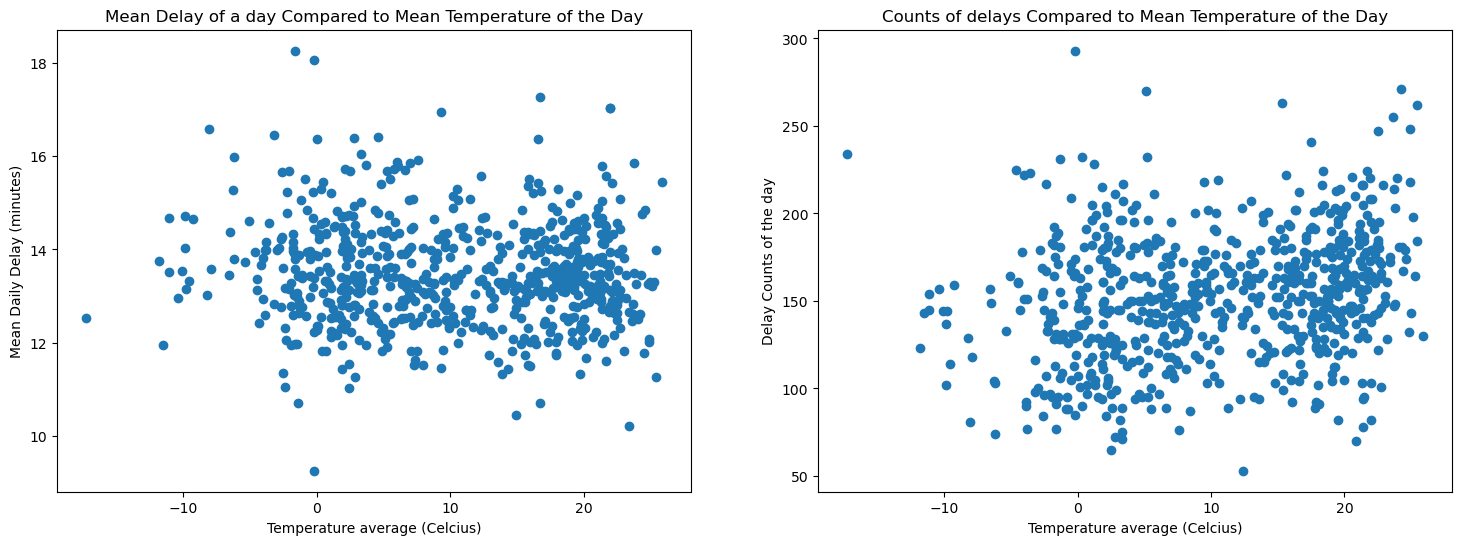

In [19]:
fig, axes = plt.subplots(1, 2, figsize = (18, 6))

axes[0].scatter(weather_data['tavg'], mean_bus_data['Min Delay'])
axes[0].set_title("Mean Delay of a day Compared to Mean Temperature of the Day")
axes[0].set_xlabel("Temperature average (Celcius)")
axes[0].set_ylabel("Mean Daily Delay (minutes)")

axes[1].scatter(weather_data['tavg'], count_bus_data['Min Delay'])
axes[1].set_title("Counts of delays Compared to Mean Temperature of the Day")
axes[1].set_xlabel("Temperature average (Celcius)")
axes[1].set_ylabel("Delay Counts of the day")
plt.show()

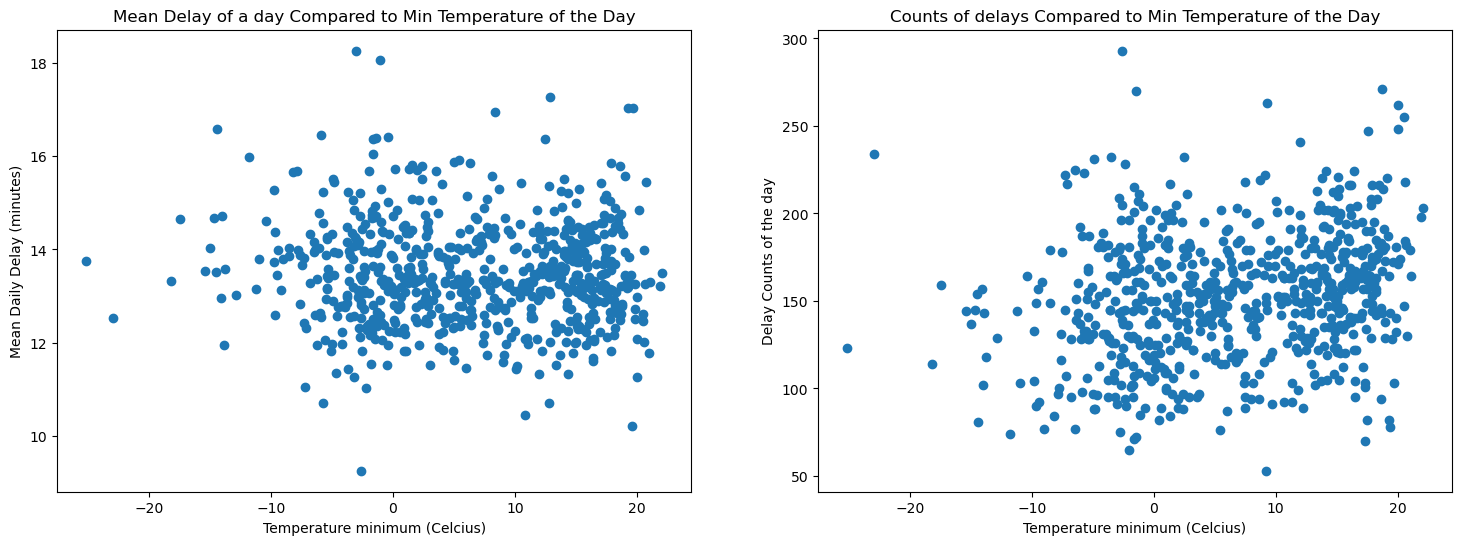

In [21]:
fig, axes = plt.subplots(1, 2, figsize = (18, 6))

axes[0].scatter(weather_data['tmin'], mean_bus_data['Min Delay'])
axes[0].set_title("Mean Delay of a day Compared to Min Temperature of the Day")
axes[0].set_xlabel("Temperature minimum (Celcius)")
axes[0].set_ylabel("Mean Daily Delay (minutes)")

axes[1].scatter(weather_data['tmin'], count_bus_data['Min Delay'])
axes[1].set_title("Counts of delays Compared to Min Temperature of the Day")
axes[1].set_xlabel("Temperature minimum (Celcius)")
axes[1].set_ylabel("Delay Counts of the day")
plt.show()

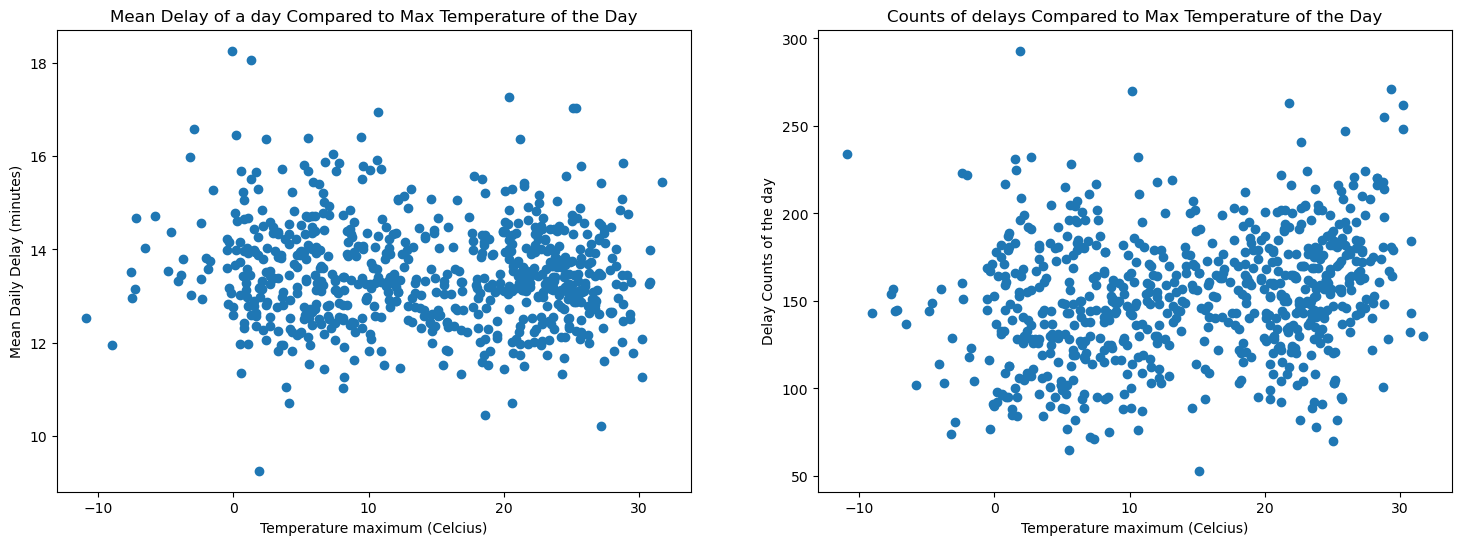

In [22]:
fig, axes = plt.subplots(1, 2, figsize = (18, 6))

axes[0].scatter(weather_data['tmax'], mean_bus_data['Min Delay'])
axes[0].set_title("Mean Delay of a day Compared to Max Temperature of the Day")
axes[0].set_xlabel("Temperature maximum (Celcius)")
axes[0].set_ylabel("Mean Daily Delay (minutes)")

axes[1].scatter(weather_data['tmax'], count_bus_data['Min Delay'])
axes[1].set_title("Counts of delays Compared to Max Temperature of the Day")
axes[1].set_xlabel("Temperature maximum (Celcius)")
axes[1].set_ylabel("Delay Counts of the day")
plt.show()

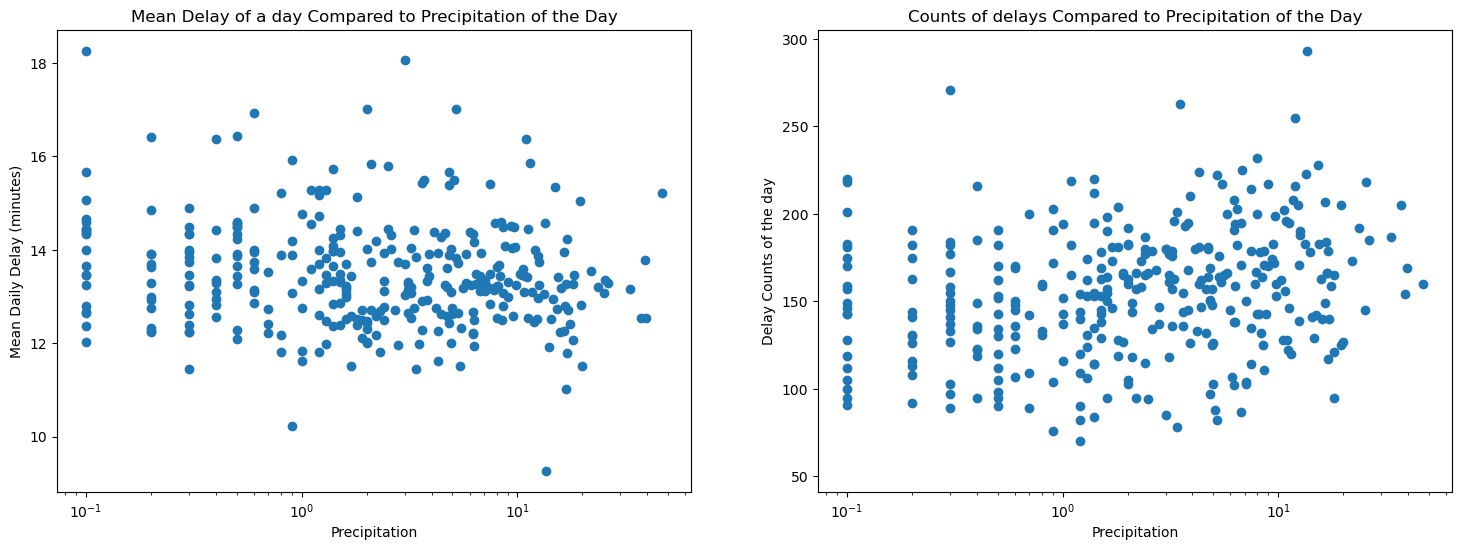

In [23]:
fig, axes = plt.subplots(1, 2, figsize = (18, 6))

axes[0].scatter(weather_data['prcp'], mean_bus_data['Min Delay'])
axes[0].set_title("Mean Delay of a day Compared to Precipitation of the Day")
axes[0].set_xlabel("Precipitation")
axes[0].set_ylabel("Mean Daily Delay (minutes)")
axes[0].set_xscale('log')

axes[1].scatter(weather_data['prcp'], count_bus_data['Min Delay'])
axes[1].set_title("Counts of delays Compared to Precipitation of the Day")
axes[1].set_xlabel("Precipitation")
axes[1].set_ylabel("Delay Counts of the day")
axes[1].set_xscale('log')

plt.show()

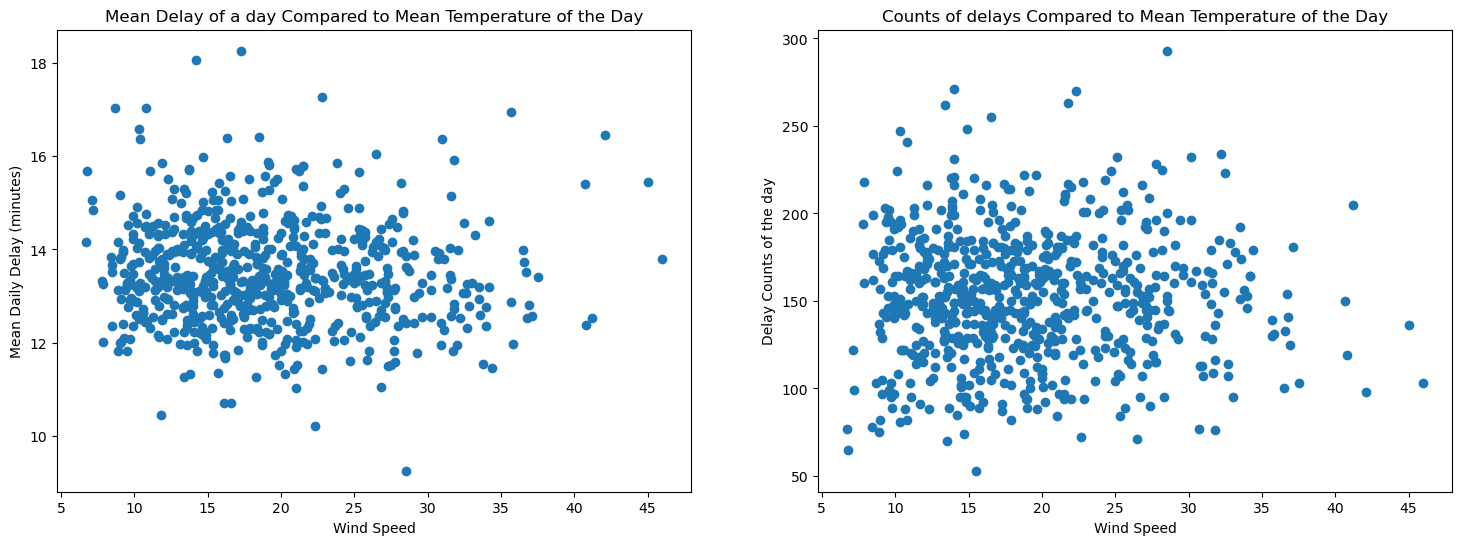

In [24]:
fig, axes = plt.subplots(1, 2, figsize = (18, 6))

axes[0].scatter(weather_data['wspd'], mean_bus_data['Min Delay'])
axes[0].set_title("Mean Delay of a day Compared to Mean Temperature of the Day")
axes[0].set_xlabel("Wind Speed")
axes[0].set_ylabel("Mean Daily Delay (minutes)")

axes[1].scatter(weather_data['wspd'], count_bus_data['Min Delay'])
axes[1].set_title("Counts of delays Compared to Mean Temperature of the Day")
axes[1].set_xlabel("Wind Speed")
axes[1].set_ylabel("Delay Counts of the day")
plt.show()

# Multiple Linear Regression

In [25]:
from sklearn.linear_model import LinearRegression

In [31]:
X = weather_data[weather_data.columns[1:]]
y = mean_bus_data['Min Delay']

good_rows = X.notna().all(axis=1)

X = X[good_rows]
y = y[good_rows]

model = LinearRegression().fit(X[:-100], y[:-100])

y_pred = model.predict(X[-100:])

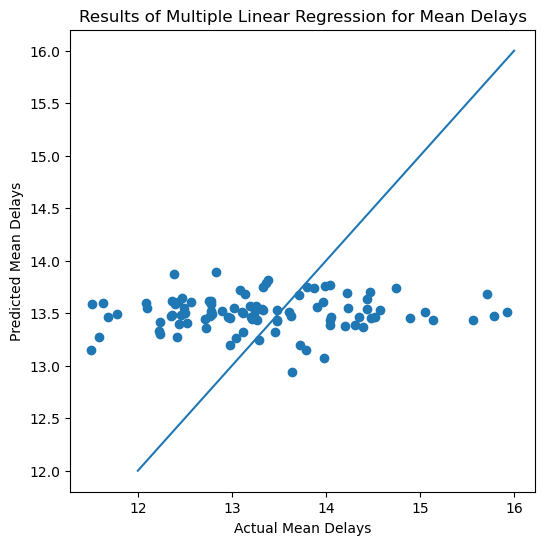

In [32]:
fig, axes = plt.subplots(1, 1, figsize = (6, 6))

axes.scatter(y[-100:], y_pred)
axes.set_title("Results of Multiple Linear Regression for Mean Delays")
axes.set_xlabel("Actual Mean Delays")
axes.set_ylabel("Predicted Mean Delays")
axes.plot(np.linspace(12, 16, 100),np.linspace(12, 16, 100))

plt.show()

In [33]:
X = weather_data[weather_data.columns[1:]]
y = count_bus_data['Min Delay']

good_rows = X.notna().all(axis=1)

X = X[good_rows]
y = y[good_rows]

model = LinearRegression().fit(X[:-100], y[:-100])

y_pred = model.predict(X[-100:])

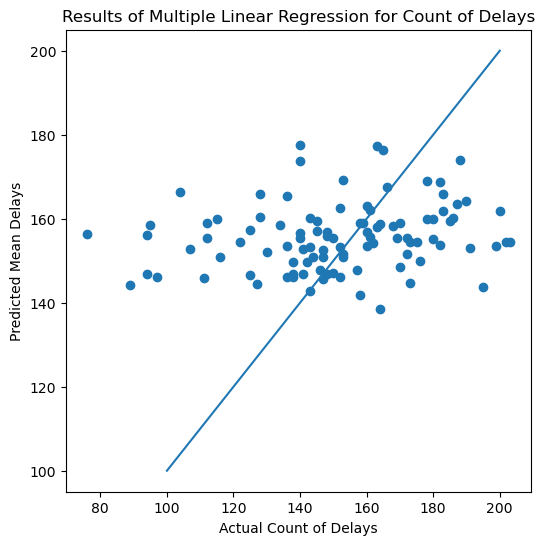

In [34]:
fig, axes = plt.subplots(1, 1, figsize = (6, 6))

axes.scatter(y[-100:], y_pred)
axes.set_title("Results of Multiple Linear Regression for Count of Delays")
axes.set_xlabel("Actual Count of Delays")
axes.set_ylabel("Predicted Mean Delays")
axes.plot(np.linspace(100, 200, 100),np.linspace(100, 200, 100))

plt.show()